/home/phuijse/Work/PLATO_spikey/.venv/lib/python3.13/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/phuijse/.config', but the default location, /home/phuijse/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


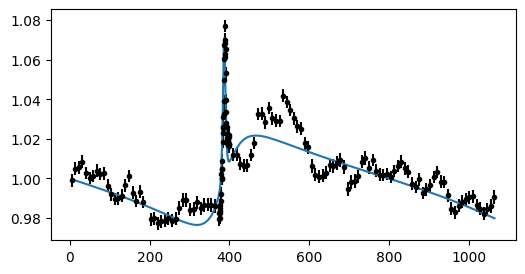

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
from functools import partial
from matplotlib import pyplot as plt
import polars as pl

import jax
from jax import random
from jax import numpy as jnp
sys.path.append('../src')
jax.config.update("jax_enable_x64", True)

import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
numpyro.enable_x64()
numpyro.set_host_device_count(4)

data_path = Path('../data')
#time, flux, flux_err = pl.read_ipc(data_path / 'lc_spikey_fiducial_1d.ftr', memory_map=False).to_numpy().T
#time, flux, flux_err = pl.read_csv(data_path / 'whitenoise_model.csv').select(['time', 'flux', 'flux_err']).to_numpy().T
#time, flux, flux_err = pl.read_csv(data_path / 'data_spikey_kepler_9day.csv').select(['time', 'flux', 'flux_err']).to_numpy().T
time, flux, flux_err = pl.read_csv(data_path / 'data_spikey_kepler_binned.csv').select(['time', 'flux', 'flux_err']).to_numpy().T

from smbhb_jax import smbhb_two_masses
from inference import make_tinygp_model, drw_kernel, smbhb_mean_builder
from plots import corner_plot, predictive_posterior

spikey_params = {
    'z': 0.918, 't0': 1.050, 'P': 1.144, 'i': 81.95, 'e': 0.524, 'w': jnp.rad2deg(1.477),
    'L': 0.89, 'alpha': 2.09, 'vz': 0, 'logM1': 7.4, 'logM2': 6.7,
}

smbhb_partial = partial(smbhb_two_masses, **spikey_params)
sim_flux = jax.vmap(smbhb_partial)(time)
fig, ax = plt.subplots(figsize=(6, 3))
ax.errorbar(time, flux, flux_err, c='k', fmt='.')
ax.plot(time, sim_flux);

## Fitting only DRW

In [3]:
#%%time

priors = {
    'tau': dist.LogNormal(jnp.log(200.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
    'mean': dist.Normal(jnp.mean(flux), 0.5),
}
time_interp = jnp.linspace(jnp.amin(time), jnp.amax(time), 500)

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors, build_kernel=drw_kernel), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time_interp)
samples = mcmc.get_samples()
print(mcmc.print_summary())

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      mean      1.00      0.01      1.00      0.99      1.01   5548.75      1.00
     sigma      0.02      0.01      0.02      0.01      0.03   4697.29      1.00
       tau     64.67     44.23     52.94     23.01    106.58   4350.41      1.00

Number of divergences: 0
None


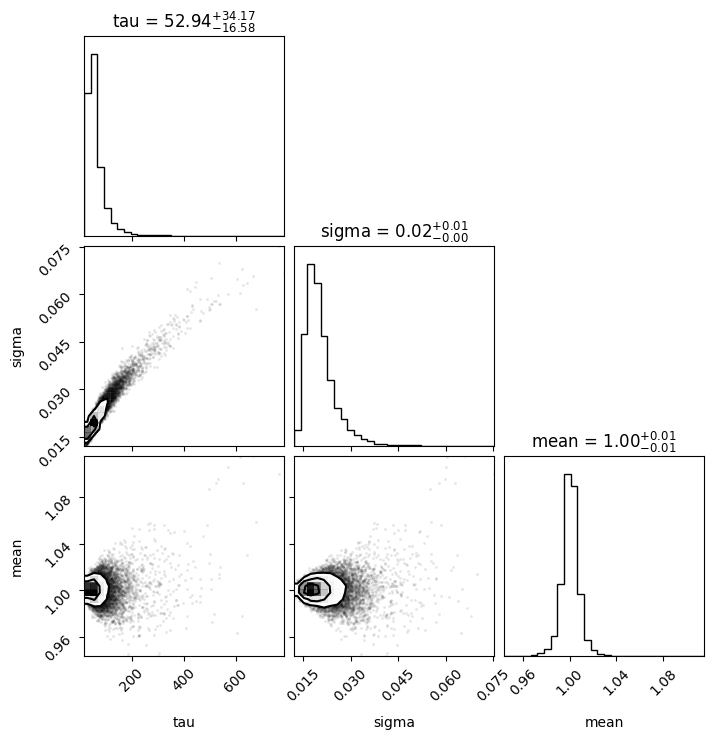

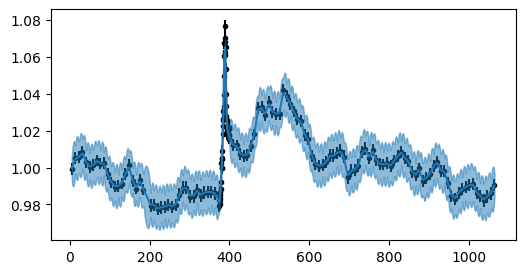

In [5]:
corner_plot(samples, list(priors.keys()), spikey_params)

fig, ax = plt.subplots(figsize=(6, 3))
ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-10)
predictive_posterior(ax, x=time_interp, samples=samples)

> DRW is perfectly capable of fitting the full time series

## Fitting DRW plus a fixed SMBHB function (spikey parameters)

In [6]:
#%%time

priors = {
    'tau': dist.LogNormal(jnp.log(200.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
}

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors | spikey_params, build_kernel=drw_kernel, build_mean=smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time_interp)
samples = mcmc.get_samples()
print(mcmc.print_summary())

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     sigma      0.01      0.00      0.01      0.01      0.01   6673.95      1.00
       tau     23.77     11.60     21.13     10.96     36.26   5466.56      1.00

Number of divergences: 0
None


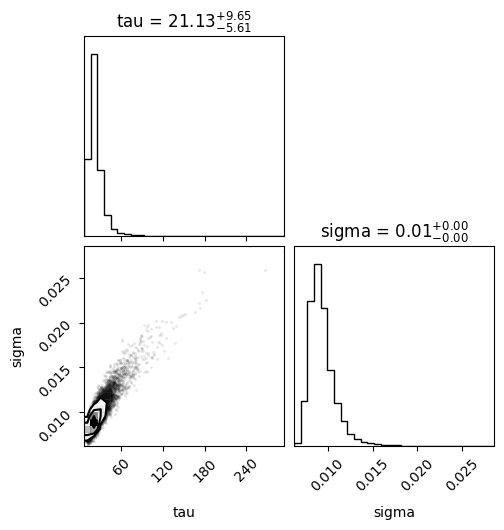

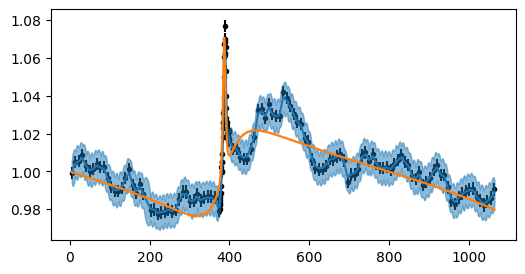

In [7]:
from plots import corner_plot
corner_plot(samples, list(priors.keys()), spikey_params)

fig, ax = plt.subplots(figsize=(6, 3))
ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-10)
predictive_posterior(ax, x=time_interp, samples=samples)

> With the SMBHB model as mean, DRW variance and time scale are smaller than in the previous case

## Fitting DRW plus a fixed SMBHB function (wrong parameters)

In [8]:
spikey_params_wrong = spikey_params.copy()
spikey_params_wrong['e'] = 0.0

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors | spikey_params_wrong, build_kernel=drw_kernel, build_mean=smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time_interp)
samples = mcmc.get_samples()
print(mcmc.print_summary())

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     sigma      0.01      0.00      0.01      0.01      0.02   7274.41      1.00
       tau     22.84      8.64     21.01     11.91     33.20   6583.97      1.00

Number of divergences: 0
None


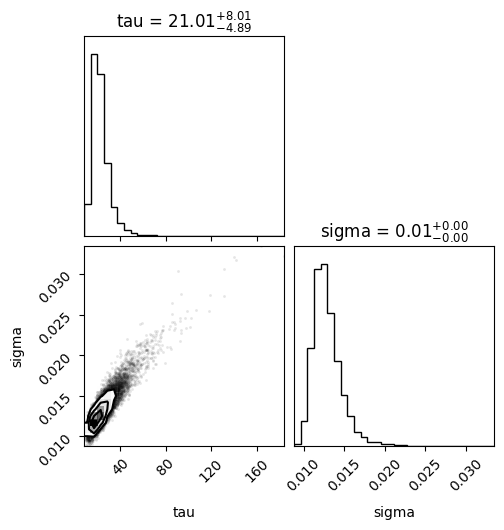

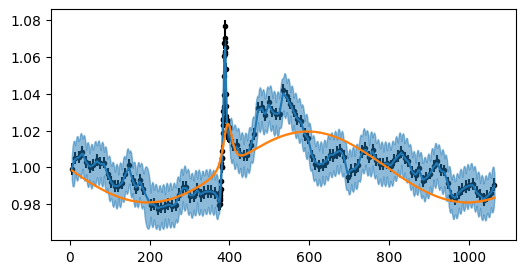

In [9]:
from plots import corner_plot
corner_plot(samples, list(priors.keys()), spikey_params)

fig, ax = plt.subplots(figsize=(6, 3))
ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-10)
predictive_posterior(ax, x=time_interp, samples=samples)

> As shown before, it does not really matter the SMBHB model is "wrong". DRW can compensate

### Same but with a more constraining prior

In [ ]:
priors = {
    'log_tau': dists.TruncatedNormal(jnp.log(200.0), 1, high=4.5),
    'log_sigma': dists.TruncatedNormal(jnp.log(jnp.std(flux)), 1, high=-4.5), 
}
    

## Fitting SMBHB (uniform priors) without DRW

In [10]:
priors = {
    'logM1': dist.Uniform(6., 11.),
    'logM2': dist.Uniform(6., 11.),
    'L': dist.Uniform(0., 1.),
    #'e': dist.Uniform(0.3, 0.7),
    'e': dist.Uniform(0.01, 0.99),
    #'w': dist.Uniform(0, 180),
    'w': dist.Uniform(0, 360),
    #'i': dist.Uniform(70, 90),
    'i': dist.Uniform(0, 90),
    'alpha': dist.Uniform(-4, 4),
    #'t0': dist.Uniform(spikey_params['t0']*0.95, spikey_params['t0']*1.05),
    #'P': dist.Uniform(spikey_params['P']*0.95, spikey_params['P']*1.05),
    't0': dist.Uniform(0, 5),
    'P': dist.Uniform(0, 5),
    'z': spikey_params['z'],
    'vz': spikey_params['vz'],
}

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors, build_kernel=None, build_mean=smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time_interp)
samples = mcmc.get_samples()
print(mcmc.print_summary())

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         L      0.27      0.20      0.23      0.03      0.53      2.06      5.90
         P      1.18      0.17      1.13      0.99      1.47      2.03      9.42
     alpha     -2.16      1.51     -2.75     -3.99      0.14      2.03      8.59
         e      0.26      0.19      0.24      0.01      0.52      2.01     17.12
         i     75.47     18.61     85.62     43.36     88.42      2.00     55.13
     logM1      7.87      1.82      7.15      6.12     10.91      2.00     32.56
     logM2      7.50      1.54      6.92      6.04     10.01      2.00     28.24
        t0      1.34      0.17      1.46      1.04      1.47      2.03      9.07
         w     22.09     33.34      1.59      0.62     79.75      2.02     10.47

Number of divergences: 5
None


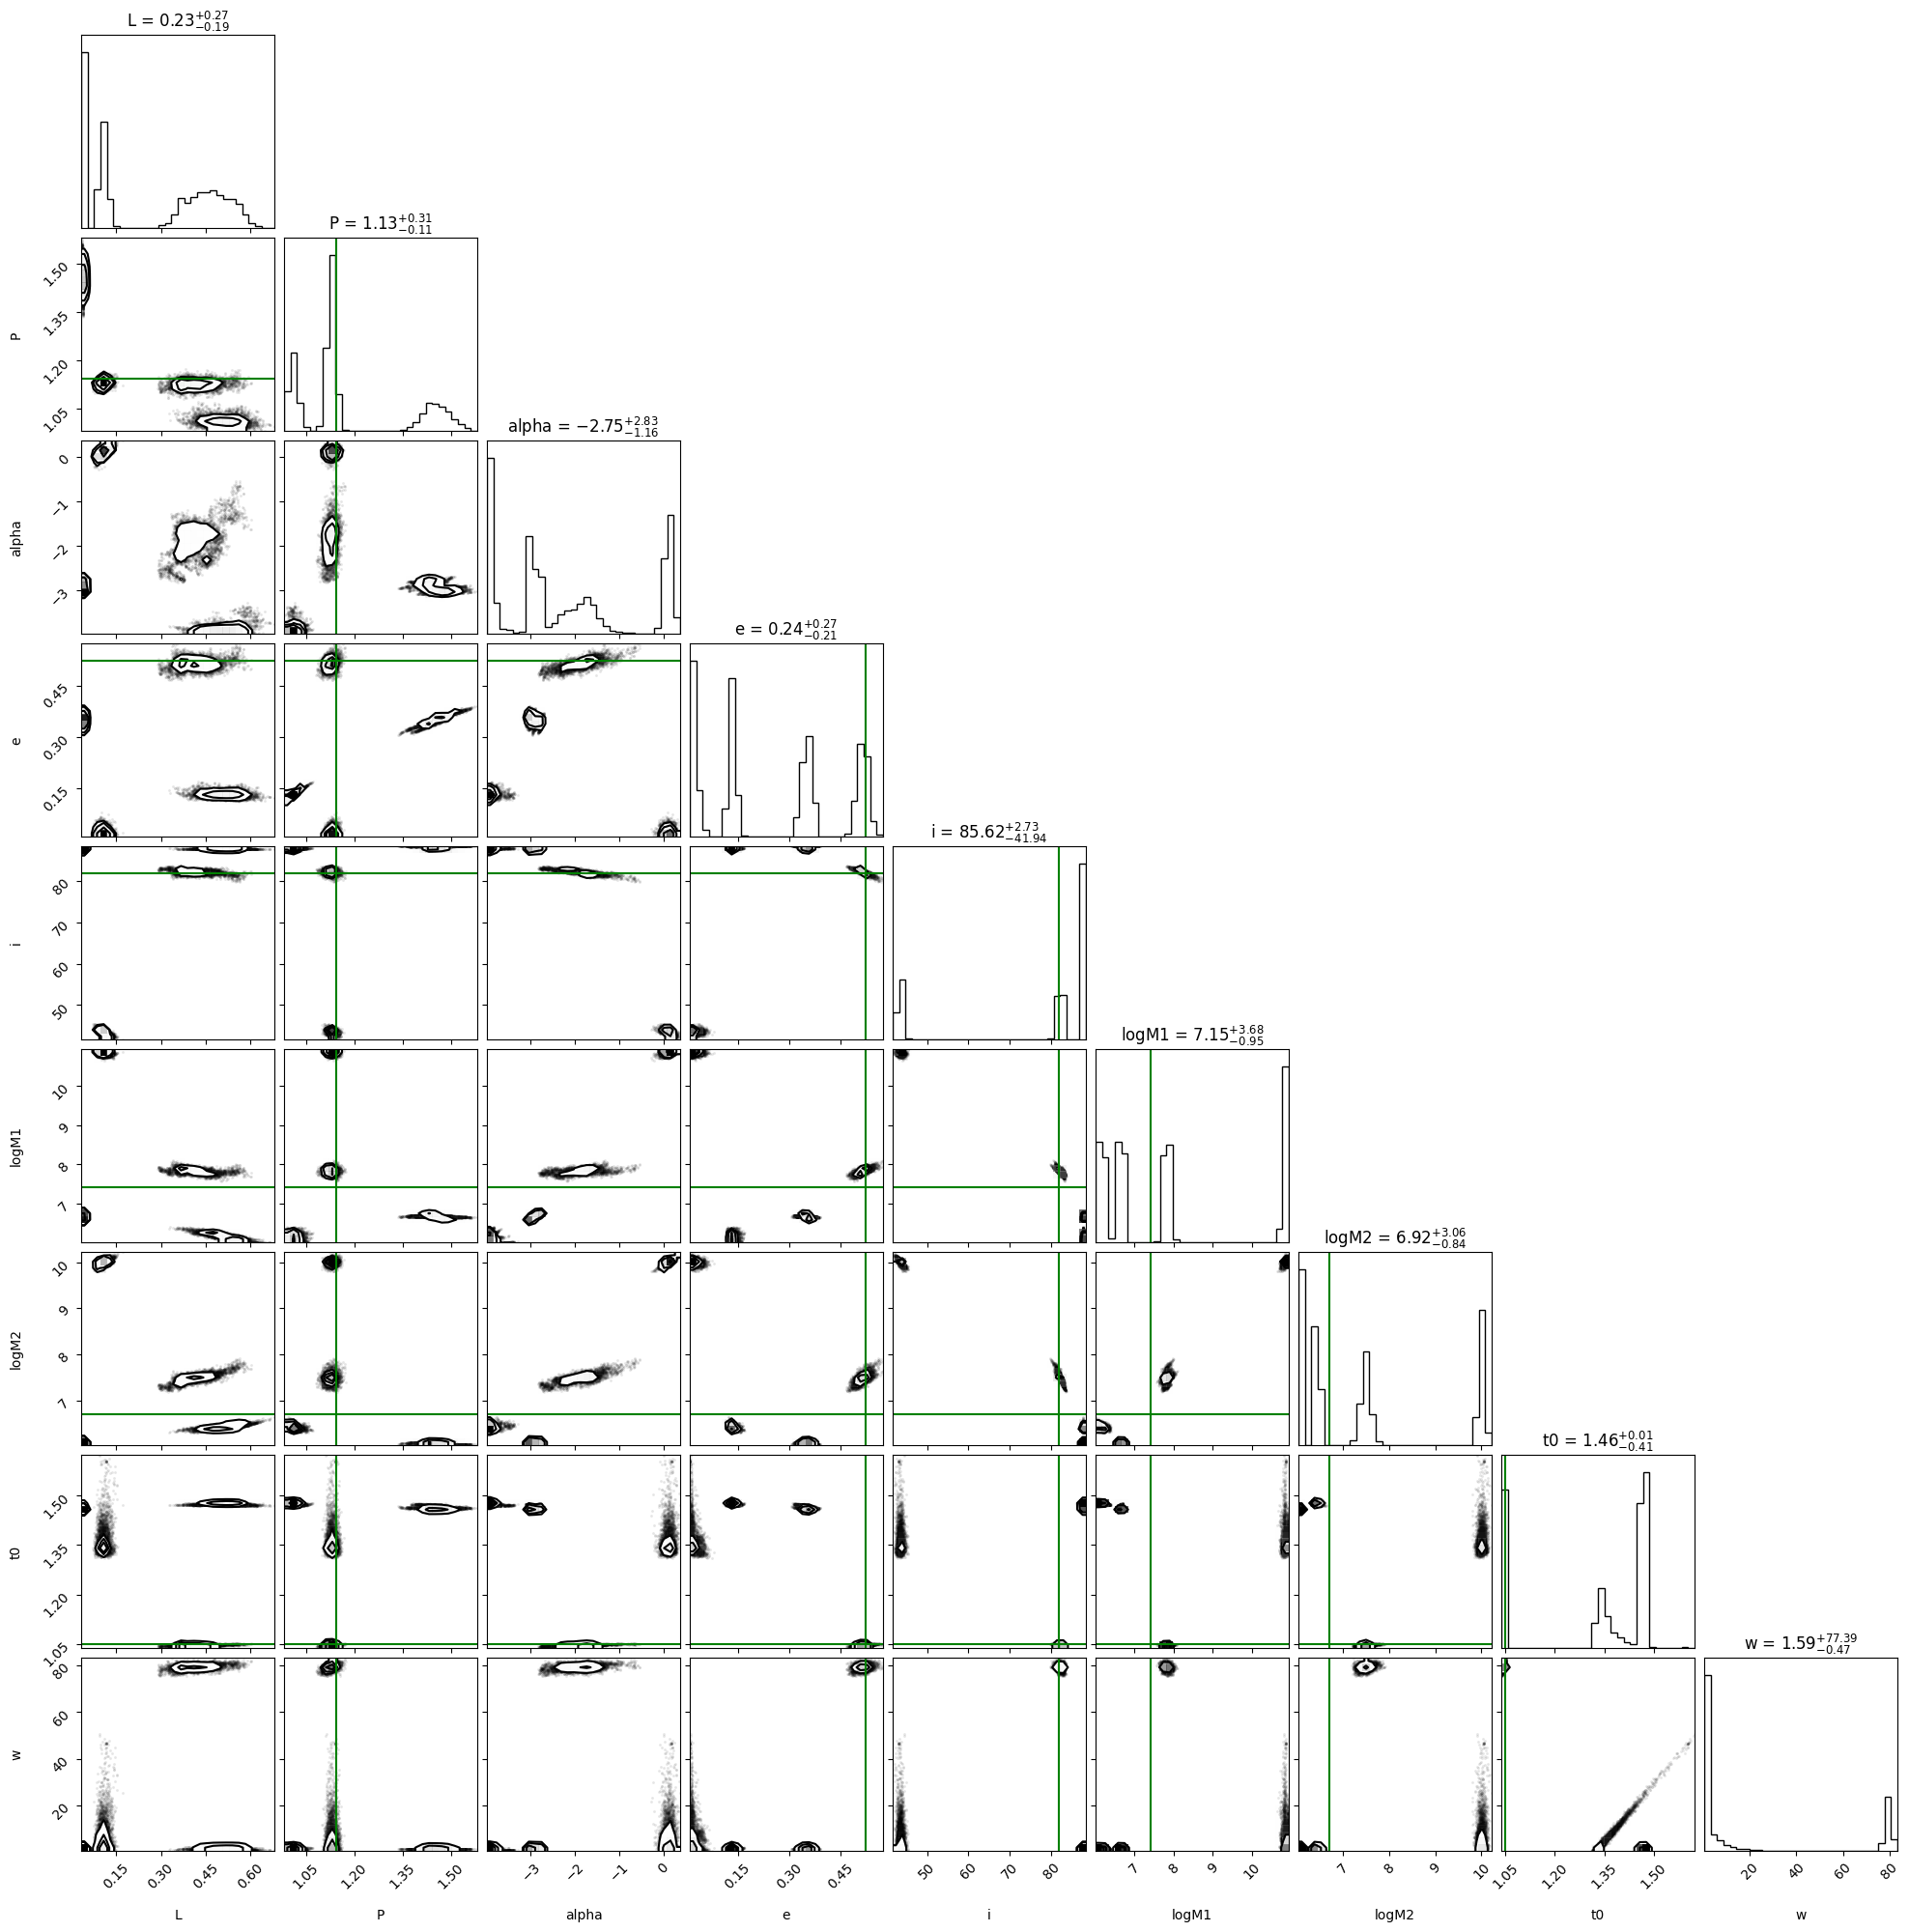

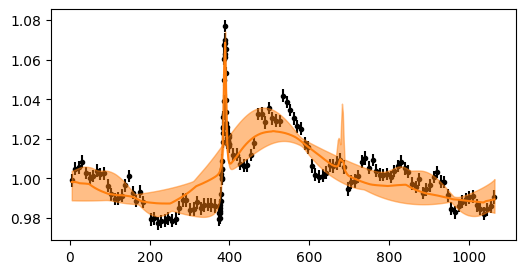

In [11]:
corner_plot(samples, true_params=spikey_params)

fig, ax = plt.subplots(figsize=(6, 3))
ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-10)
predictive_posterior(ax, x=time_interp, samples=samples)

## Fitting SMBHB (uniform priors) with DRW

In [12]:
#%%time

priors = {
    'logM1': dist.Uniform(6., 11.),
    'logM2': dist.Uniform(6., 11.),
    'L': dist.Uniform(0., 1.),
    'e': dist.Uniform(0.01, 0.99),
    'w': dist.Uniform(0, 360),
    'i': dist.Uniform(0, 90),
    'alpha': dist.Uniform(-4, 4),
    't0': dist.Uniform(0, 5),
    'P': dist.Uniform(0, 5),
    'z': spikey_params['z'],
    'vz': spikey_params['vz'],
    'tau': dist.LogNormal(jnp.log(200.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
}

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors, build_kernel=drw_kernel, build_mean=smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time_interp)
samples = mcmc.get_samples()
print(mcmc.print_summary())

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         L      0.66      0.27      0.64      0.26      1.00      4.32      1.57
         P      2.14      0.85      2.03      0.98      3.51     51.51      1.13
     alpha      0.91      2.51      2.22     -3.42      2.85      2.01     14.10
         e      0.93      0.03      0.94      0.88      0.96      4.66      1.42
         i     40.18     14.35     40.06     18.41     61.83      3.39      1.71
     logM1      7.63      1.08      7.24      6.51      9.47      2.52      2.24
     logM2      8.01      1.17      7.47      6.20      9.62      2.32      3.03
     sigma      0.01      0.00      0.01      0.01      0.02      3.14      1.66
        t0      2.04      1.69      1.07      1.06      4.98      2.00    375.93
       tau    220.65    240.49    129.38     15.67    568.87      3.00      1.72
         w    240.63     86.71    225.16    137.38    341.66      2.01     12.59

Number of divergences: 514

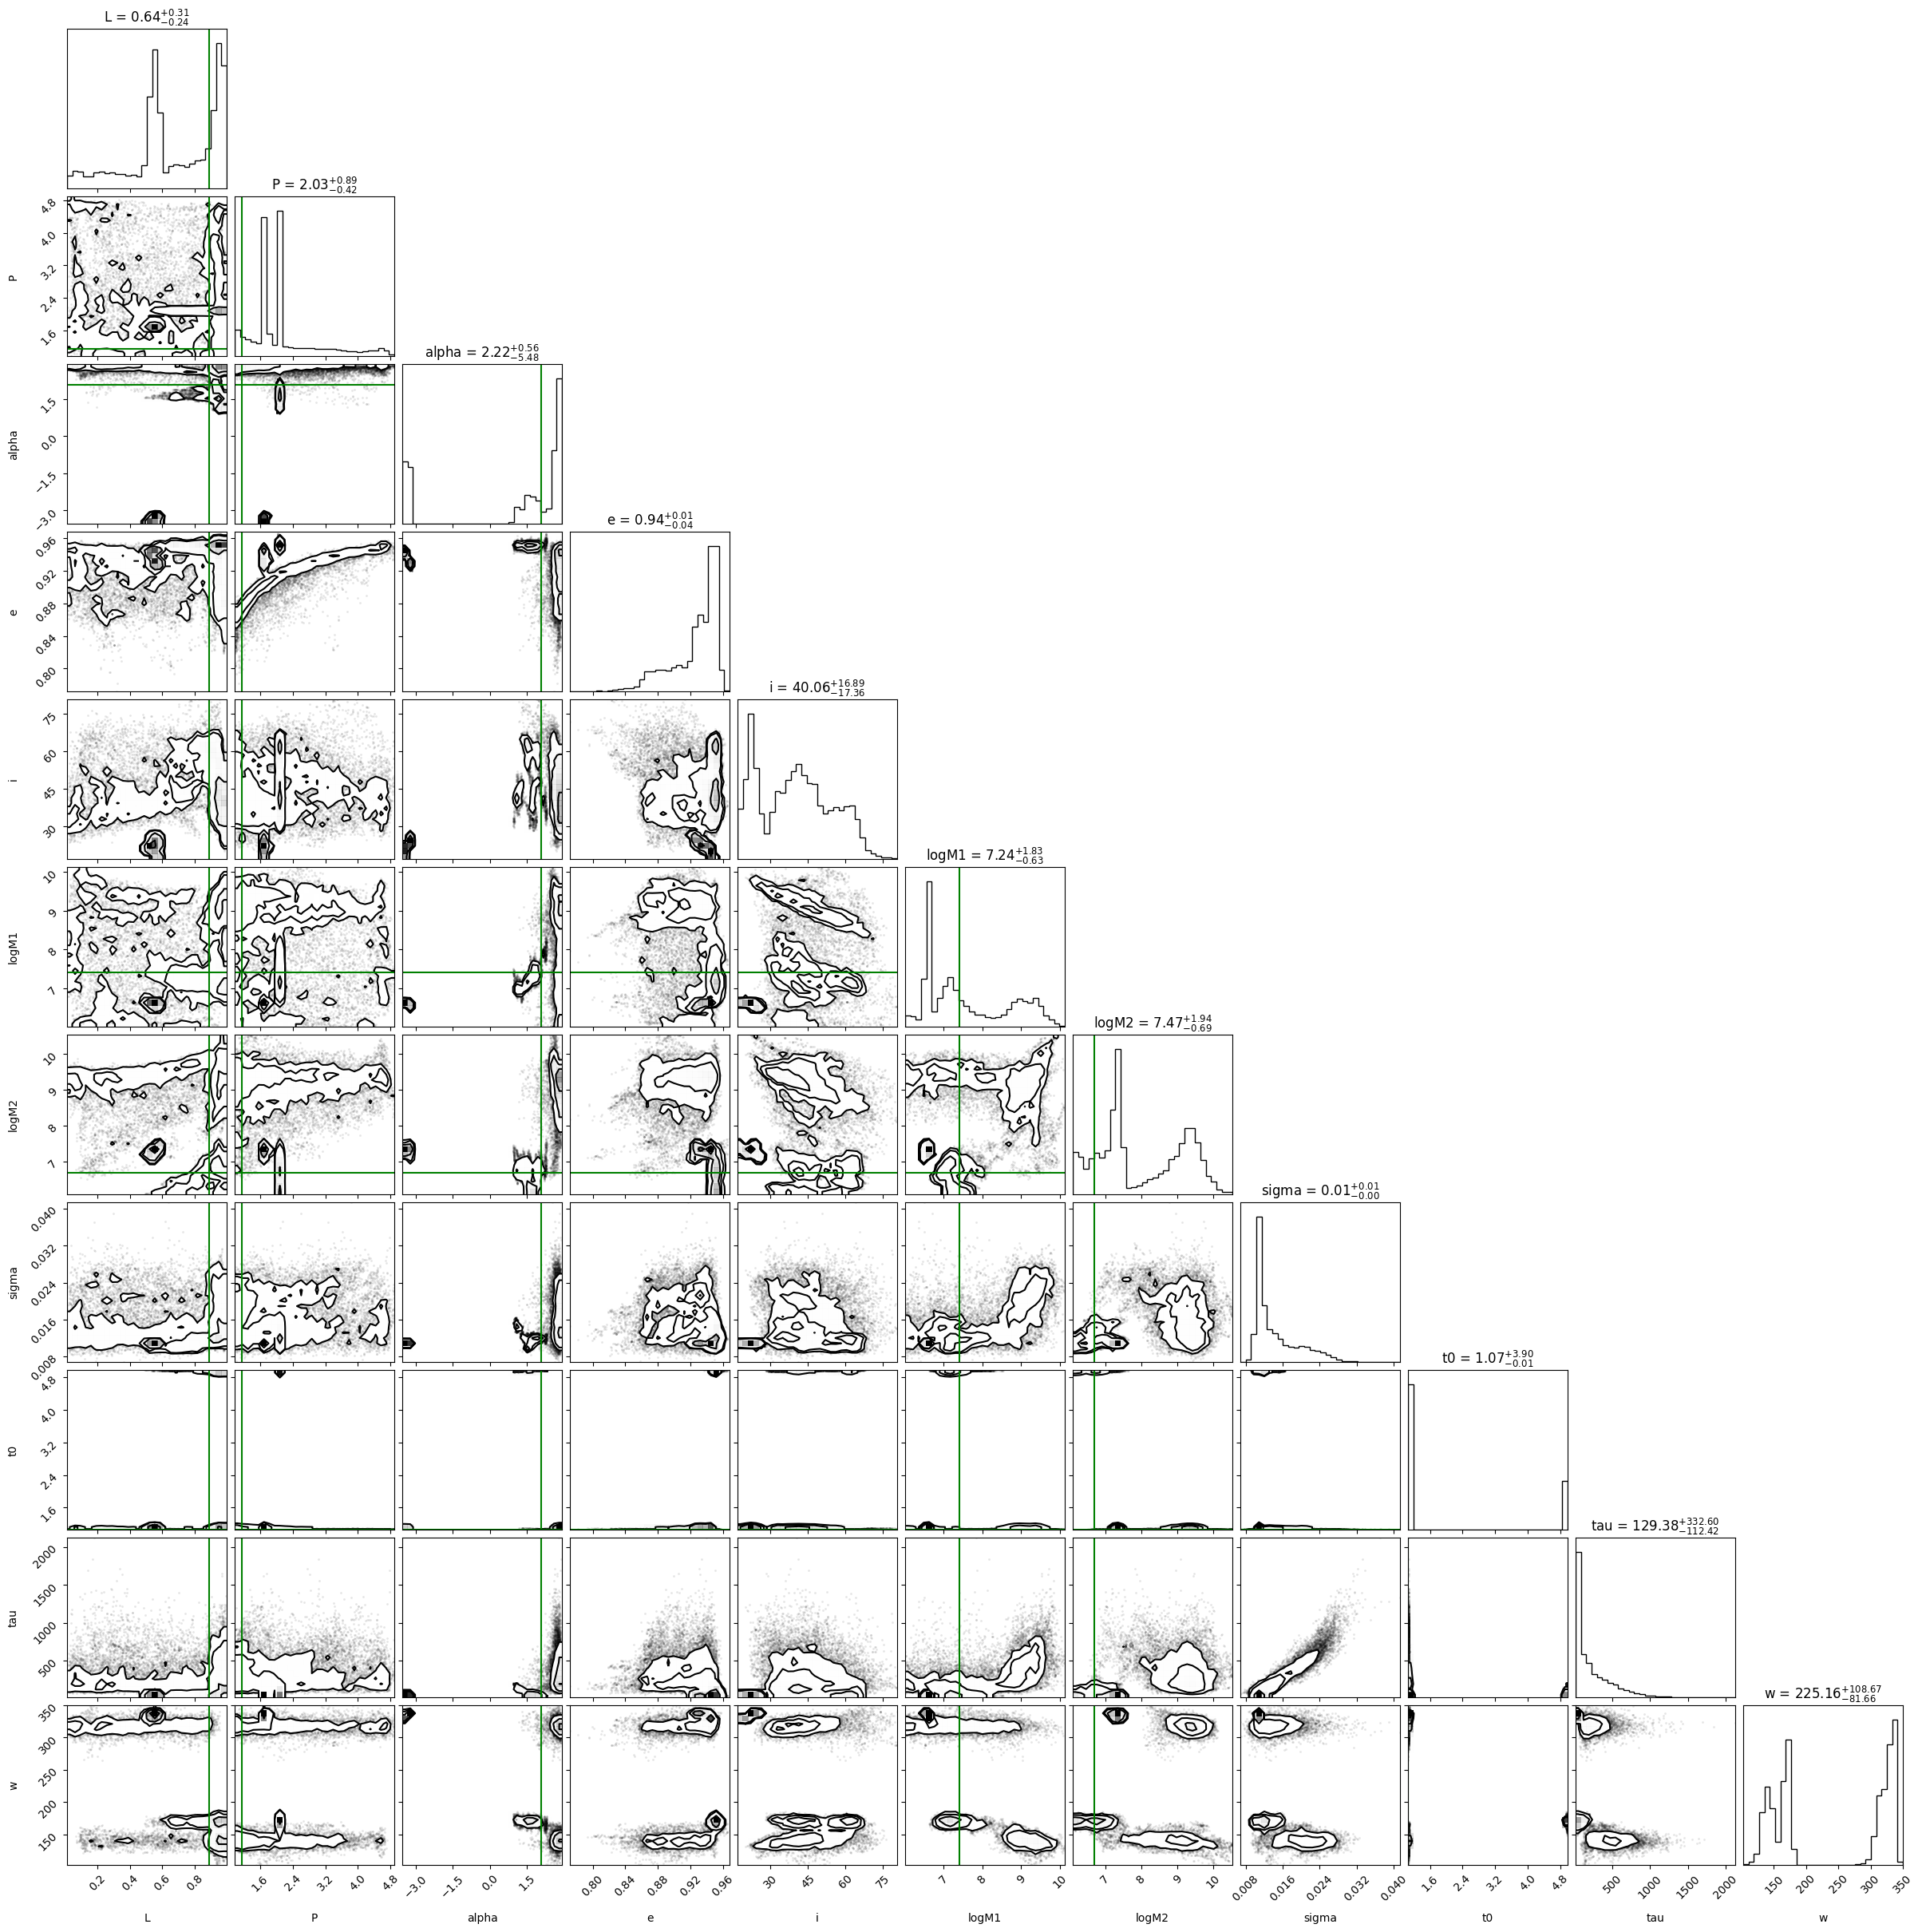

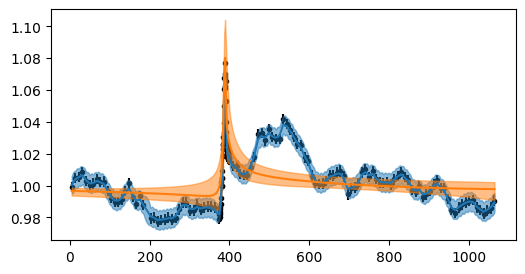

In [13]:
corner_plot(samples, true_params=spikey_params)

fig, ax = plt.subplots(figsize=(6, 3))
ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-10)
predictive_posterior(ax, x=time_interp, samples=samples)

## Full SMBHB plus DRW (constrained DRW)

In [ ]:
#%%time

priors = {
    'log_tau': dists.TruncatedNormal(jnp.log(200.0), 1, low=jnp.log(50), high=4.5),
    'log_sigma': dists.TruncatedNormal(jnp.log(jnp.std(flux)), 1, high=-4.5), 
    'logMtot': dists.Uniform(6., 11.),
    'eta_logq': dists.Normal(0.0, 1.0),
    'L': dists.Uniform(0., 1.),
    #'L': dists.Uniform(
    "eta_alpha": dists.Normal(0.0, 1.0),
    "eta_w": dists.Normal(0.0, 1.0),
    'eta_i': dists.Normal(0.0, 1.0),
    't0': dists.Uniform(sim_params['t0']*0.95, sim_params['t0']*1.05),
    'eta_e': dists.Normal(0.0, 1.0),
    'P': dists.Uniform(sim_params['P']*0.95, sim_params['P']*1.05),
}

time_interp = jnp.linspace(jnp.amin(time), jnp.amax(time), 500)

def box_constraint(eta, min_val, max_val):
    return min_val + (max_val-min_val)*jax.nn.sigmoid(eta)

def full_model(x, yerr, y=None):
    params = {k: numpyro.sample(k, v) for k, v in priors.items()} 
    #params['L'] = numpyro.deterministic('L', box_constraint(params['eta_L'], 1e-4, 1. - 1e-4))
    cos_i = box_constraint(params['eta_i'], jnp.cos(jnp.deg2rad(90.0)), jnp.cos(jnp.deg2rad(70.0)))
    params['i'] = numpyro.deterministic("i", jnp.rad2deg(jnp.arccos(cos_i)))
    params['e'] = numpyro.deterministic("e", box_constraint(params['eta_e'], 0.3, 0.7))
    #params['w'] = numpyro.deterministic('w', jnp.rad2deg(box_constraint(params['eta_w'], 0.0, jnp.pi)))
    params['w'] = numpyro.deterministic('w', jnp.rad2deg(box_constraint(params['eta_w'], np.deg2rad(sim_params['w']*0.9), np.deg2rad(sim_params['w']*1.1))))
    params['alpha'] = numpyro.deterministic('alpha', box_constraint(params['eta_alpha'], sim_params['alpha']*0.8, sim_params['alpha']*1.2))
    logq = box_constraint(params['eta_logq'], -2., 0.)        
    # logMtot = log(M1 + M2) = log(M1 + M1*q) = log(M1(1+q)) = log(M1) + log(1 +q)
    params['logM1'] = numpyro.deterministic('logM1', params['logMtot'] - jnp.log10(1. + 10.0**logq))
    # log(q) = log(M2) - log(M1)
    params['logM2'] = numpyro.deterministic('logM2', params['logM1'] + logq)
    
    params['vz'] = sim_params['vz']
    params['z'] = sim_params['z']
    
    mean_fn = partial(smbhb_twomass, **params)
    sigma = jnp.exp(params['log_sigma'])
    tau = jnp.exp(params['log_tau'])
    gp = GaussianProcess(sigma**2 * kernels.quasisep.Exp(scale=tau), x, diag=yerr**2, mean=mean_fn)
    numpyro.sample("gp", gp.numpyro_dist(), obs=y)
    if y is not None:
        numpyro.deterministic("pred_smbhb", jax.vmap(mean_fn)(time_interp))
        cond_gp = gp.condition(y, time_interp).gp
        numpyro.deterministic("pred_gp_mean", cond_gp.loc)
        numpyro.deterministic("pred_gp_std", jnp.sqrt(cond_gp.variance))
        
nuts_kernel = numpyro.infer.NUTS(full_model, target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = numpyro.infer.MCMC(
    nuts_kernel,
    num_warmup=2000,
    num_samples=4000,
    num_chains=4,
    progress_bar=True,
    chain_method='parallel',
    jit_model_args=True,
)
rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err)
samples = mcmc.get_samples()
print(mcmc.print_summary())